In [19]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 
import time
import math

# exercise_7

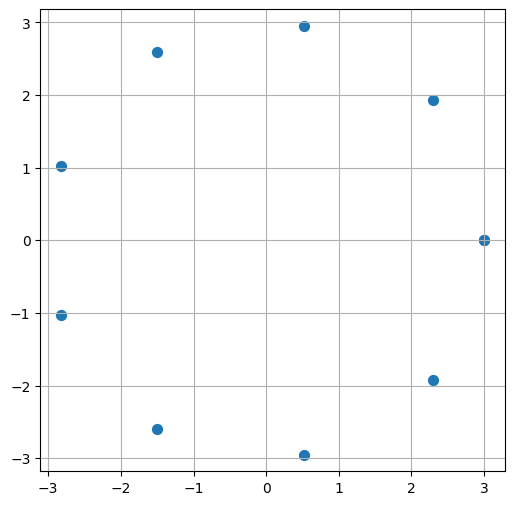

In [ ]:
n = 10
radius = 3

angles = np.linspace(0, 2*np.pi, n)
points = np.column_stack([radius*np.cos(angles), radius*np.sin(angles)])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=50)
plt.axis('equal')
plt.show()

In [ ]:
def cost_function(x1, x2):
    return np.linalg.norm(x1 - x2)

def route_cost(points, route):
    total_cost = 0
    for i in range(len(route)):
        current = route[i]
        next_point = route[(i+1) % len(route)] 
        total_cost += cost_function(points[current], points[next_point])
    return total_cost

def cooling_1(k):
    return 1/np.sqrt(1+k)

def cooling_2(k):
    return 1/np.log(2+k)


def find_best_route(points, x0, N):
    n = len(x0)
    x = np.copy(x0)
    best_x = np.copy(x0)
    best_cost = route_cost(points, best_x)
    for i in range(N):
        one = np.random.randint(0, n)  
        two = np.random.randint(0, n)
        
        x_new = np.copy(x)
        x_new[one], x_new[two] = x_new[two], x_new[one]
        
        cost_current = route_cost(points, x)
        cost_new = route_cost(points, x_new)
        if cost_new < cost_current or np.random.uniform(0,1) <= np.exp(-(cost_new-cost_current) / cooling_2(i)):
            x = x_new
        else:
            best_x = np.copy(x_new)
            best_cost = cost_new
    
    return best_x, best_cost


initial_route = np.random.permutation(np.arange(len(points)))
best_route, best_cost = find_best_route(points, initial_route, 5)

best_cost,best_route

(np.float64(40.649231531146114), array([4, 2, 6, 9, 1, 3, 8, 7, 0, 5]))

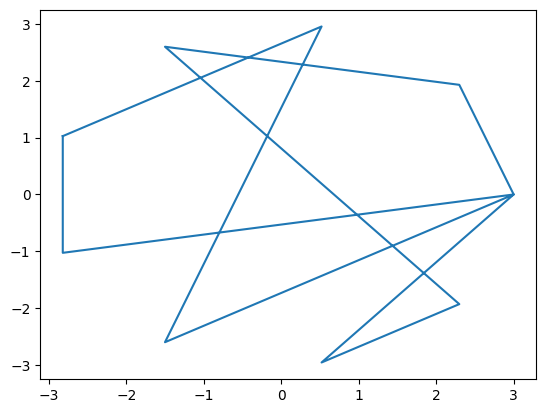

In [65]:
route_closed = np.append(best_route, best_route[0])
plt.plot(points[route_closed, 0], points[route_closed, 1])

In [73]:
def route_cost(cost, route):
    total_cost = 0
    for i in range(len(route)):
        current = route[i]
        next_point = route[(i+1) % len(route)]
        total_cost += cost[current][next_point]   # direct lookup, no norm
    return total_cost


def find_best_route(points, x0, N):
    n = len(x0)
    x = np.copy(x0)
    best_x = np.copy(x0)
    best_cost = route_cost(points, best_x)
    for i in range(N):
        one = np.random.randint(0, n)  
        two = np.random.randint(0, n)
        
        x_new = np.copy(x)
        x_new[one], x_new[two] = x_new[two], x_new[one]
        
        cost_current = route_cost(points, x)
        cost_new = route_cost(points, x_new)
        if cost_new < cost_current or np.random.uniform(0,1) <= np.exp(-(cost_new-cost_current) / cooling_2(i)):
            x = x_new
        else:
            best_x = np.copy(x_new)
            best_cost = cost_new
    
    return best_x, best_cost


In [74]:
cost = np.genfromtxt("cost.csv",delimiter=",")

In [134]:
initial_route = np.random.permutation(np.arange(len(cost)))
best_route, best_cost = find_best_route(cost, initial_route, 10_000)
best_cost

np.float64(2167.0)